### Imports

In [1]:
import torch
import torch.nn as nn
import copy
import random
import numpy as np
import torch.optim as optim
from tqdm.notebook import tqdm, trange
from torchvision import datasets, transforms
import time
import gc
from GPUtil import showUtilization as gpu_usage
from GPUtil import getGPUs
from torchvision.transforms import v2
import os, ctypes
from IPython.core.display import HTML
import os
import shutil
import json
from pathlib import Path
import opendatasets as od
from torch.utils.data import Dataset, DataLoader
import re
from matplotlib import pyplot as plt

# For the correct functioning of tqdm
display(HTML("""
    <style>
        .jp-OutputArea-child:has(.jp-OutputArea-prompt:empty) {
              padding: 0 !important;
        }
    </style>
"""))

# To supress pesky warnings
import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'GPUtil'

### Reproducibility

In [2]:
def set_seed(seed_value=42):
    np.random.seed(seed_value) # cpu vars
    random.seed(seed_value) # Python
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    os.environ['CUBLAS_WORKSPACE_CONFIG']=":4096:8"
    torch.manual_seed(seed_value) # cpu  vars
    torch.use_deterministic_algorithms(True,warn_only=True)
    torch.cuda.manual_seed_all(seed_value) # gpu vars
    torch.backends.cudnn.deterministic = True  #needed
    torch.backends.cudnn.benchmark = False

# 0. Useful functions

In this section we define all the functions we need, from creating and training the models to generating the datasets or cleaning unused memory.

### 0.1. Memory management

In [3]:
# Here we define a function to free all possible memory from the GPU to avoid memory issues when dealing with a lot of models
def free_gpu_cache(show_usage = False):
# This function is used to clear the GPU cache and avoid memory problems when dealing with large populations and big models
    if show_usage:
        print("Initial GPU Usage")
        gpu_usage()
    torch.cuda.ipc_collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    gc.collect()
    if show_usage:
        print("GPU Usage after emptying the cache")
        gpu_usage()

### 0.2. Model training functions

In [4]:
def trainloop(base_model, transforms, max_epochs = 256, lr = 1e-3, patience = 0, model_save_path = "", verbose = False):
    try:
        accs = {"train" : [],
                "val" : [],
                "test" : []
               }
        times = []
        with tqdm(total = len(transforms), leave = False, desc='Data Augmentation scheme') as pbar0:
            for t_idx, t in enumerate(transforms):
                model = copy.deepcopy(base_model)
                
                if t_idx == len(transforms)-1: # For the no Data Aug. with reinitialized weights case
                    model.apply(weight_reset)
                
                start = time.time()
                val_loader, train_loader = retrieve_datasets(t)
        
                model.to(model.device)
                optimizer = optim.AdamW(model.parameters(), lr)
                
                model.train()
                training_loss = []
                validation_loss = []
                overfit = 0
                best_loss = np.inf
                with tqdm(total = max_epochs , leave = False, desc='Training model') as pbar1:
                    for epoch in range(max_epochs ):
                        running_loss = 0.0
                        for inputs, labels in train_loader:
                            inputs = t(inputs)
                            time_start = time.time()
                            inputs, labels = inputs.to(model.device), labels.to(model.device)
                            optimizer.zero_grad()
                            outputs = model(inputs)
                            
                            loss = criterion(outputs, labels)
                            loss.backward()
                            optimizer.step()
                            running_loss += loss.item()

                            if time.time() - time_start > model.max_iter_time:
                                pbar0.update(np.inf)
                                pbar1.update(np.inf)
                                del model, optimizer
                                free_gpu_cache()
                                raise Exception("This model would take too much time to train. Trying another random model.")
                        training_loss.append(running_loss/len(train_loader))
                        
                        model.eval()
                        running_loss = 0.
                        with tqdm(total=len(val_loader), leave = False, desc='Calculating validation loss') as pbar3:
                            with torch.no_grad():
                                for inputs, labels in val_loader:
                                    inputs, labels = inputs.to(model.device), labels.to(model.device)
                                    outputs = model.forward(inputs)
                                    loss = criterion(outputs, labels)
                                    running_loss += loss.detach().cpu().numpy()
                                    pbar3.update(1)
                        validation_loss.append(running_loss/len(val_loader))
                
                        if patience > 0:
                            if validation_loss[-1] < best_loss:
                                best_loss = validation_loss[-1]
                                overfit = 0
                                torch.save(model.state_dict(), "training_model.pt")
                            else:
                                overfit += 1
                            if overfit >= patience:
                                pbar1.update(max_epochs )
                                break
                        pbar1.update(1)

                if verbose:
                    plt.plot(training_loss)
                    plt.plot(validation_loss)
                    plt.legend(["Train","Val"])
                    plt.show()
                if patience > 0:
                    model.load_state_dict(torch.load("training_model.pt"))

                running_loss = 0.
                with tqdm(total=len(test_loader), leave = False, desc='Calculating test loss') as pbar3:
                    with torch.no_grad():
                        for inputs, labels in test_loader:
                            inputs, labels = inputs.to(model.device), labels.to(model.device)
                            outputs = model.forward(inputs)
                            loss = criterion(outputs, labels)
                            running_loss += loss.detach().cpu().numpy()
                            pbar3.update(1)
                print("Test batch prediction example:")
                print("Outputs:", outputs)
                print("Labels: ", labels)
        
                accs["train"] = accs["train"] + copy.deepcopy([training_loss[-1]])
                accs["val"] = accs["val"] + copy.deepcopy([validation_loss[-1]])
                accs["test"] = accs["test"] + copy.deepcopy([running_loss/len(test_loader)])
                
                torch.save(model, "data_aug_"+str(t_idx)+".pt")
                
                del model, optimizer, loss, inputs, labels, outputs
                times += [time.time()-start]
                
                pbar0.update()
                free_gpu_cache()
        
        valid = np.sum([accs["val"][i]>0.2 for i in range(len(transforms))]) == len(transforms)
        for t_idx in range(len(transforms)):
            shutil.copyfile("data_aug_"+str(t_idx)+".pt", model_save_path+"data_aug_"+str(t_idx)+"/"+str(len(os.listdir(model_save_path+"data_aug_"+str(t_idx))))+".pt")
        return accs, times
    
    except Exception as e:
        pbar0.update(np.inf)
        pbar1.update(np.inf)
        print("Error during training")
        del model, optimizer
        free_gpu_cache()
        raise Exception()


### 0.3. Model generation

In [5]:
class conv_block(nn.Module):
    def __init__(self, in_c, out_c, kernel_size = 3):
        self.kernel_size = kernel_size
        padding = int((kernel_size + 1)/2)
        self.padding = padding
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, kernel_size=kernel_size, padding=padding)
        self.bn = nn.BatchNorm2d(out_c)
        self.relu = nn.ReLU()
        
    def forward(self, inputs):
        x = self.conv(inputs)
        x = self.bn(x)
        x = self.relu(x)
        return x  

class block(nn.Module):
    def __init__(self, in_c, out_c, resizing_type = None, from_block_channels = 0, kernel_size = 3):
        super().__init__()
        self.resizing_type = resizing_type
        self.kernel_size = kernel_size
        self.in_c = in_c
        self.out_c = out_c
        self.from_block_channels = from_block_channels
        
        if resizing_type == "D":
            self.resizing = nn.MaxPool2d((2, 2))
        elif resizing_type == "U":
            self.resizing = nn.ConvTranspose2d(in_c, in_c, kernel_size=2, stride=2, padding=0)
        else:
            self.resizing = nn.Identity()
        
        self.conv = conv_block(from_block_channels+in_c, out_c, kernel_size = kernel_size)
        
    def forward(self, inputs, skip):
        x = self.resizing(inputs)
        
        for extra_input in skip:
            x = torch.cat([x, nn.functional.interpolate(extra_input, size = [x.shape[2], x.shape[3]])], axis=1)
        x = self.conv(x)
        return x

class optimized_network(nn.Module):
    """
    A Convolutional Neural Network generated randomly.
    """
    def __init__(self, dataloader, n_blocks = 1, task = "infere", out_size = None, logmin_c = 5, logmax_c = 8, max_k = 9, complex_classifier = False, max_iter_time = 1, verbose = False):
        super().__init__()
        
        if hasattr(n_blocks, '__iter__'):
            if len(n_blocks) not in [1,2]:
                raise Exception("Invalid range for model initial layers.")
        elif n_blocks == int(n_blocks):
            n_blocks = [int(n_blocks), int(n_blocks)]
        else:
            raise Exception("Model initial layers needs to be either a scalar or a scalar range.")

        self.dataloader = dataloader
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.logmin_c = logmin_c
        self.logmax_c = logmax_c
        self.max_k = max_k
        self.complex_classifier = complex_classifier
        self.max_iter_time = max_iter_time
        
        batch = next(iter(dataloader))
        self.in_size = batch[0].shape
        self.label_size = batch[1].shape
        
        if task not in ["image_to_image", "image_to_mask", "object_detection", "regression", "classification", "infere"]:
            print("Unknown task. Infering task from dataset.")
            task = "infere"
        if task == "infere":
            if batch[0].shape[-2:] == batch[1].shape[-2:]:
                if batch[1].is_floating_point():
                    self.task = "image_to_image"
                else:
                    if batch[1].shape[-3] == 1:
                        self.task = "image_to_mask"
                    else:
                        self.task = "object_detection"
            else:
                if batch[1].is_floating_point():
                    self.task = "regression"
                else:
                    self.task = "classification"
        else:
            self.task = task
        
        if out_size:
            self.out_size = out_size
        else:
            if self.task == "classification" or self.task == "object_detection":
                targets = dataloader.dataset.targets
                self.out_size = max(targets) + 1
            else:
                self.out_size = batch[1].shape[1:]
                if len(batch[1].shape)==1: self.out_size = [1]
                
        
        invalid = self.initialize_network(n_blocks = random.randint(n_blocks[0], n_blocks[1]), verbose = verbose)
        if invalid:
            del self.features, self.fc
            free_gpu_cache()

    def calculate_possible_connections(self):
        updown = [0]
        for l in self.features:
            if type(l.resizing) == nn.Identity:
                r = 0
            elif type(l.resizing) == nn.ConvTranspose2d:
                r = 1
            elif type(l.resizing) == nn.MaxPool2d:
                r = -1
            updown = updown + [updown[-1] + r]
        updown = updown[1:]
    
        possible_connections = []
        for idxin, lin in enumerate(updown):
            for idxout, lout in enumerate(updown[idxin+2:]):
                if lin == lout:
                    possible_connections += [(idxin, idxin+2+idxout)]
        
        return possible_connections
    
    def correct_blocks(self):
        for l, blk in enumerate(list(self.features.children())): # We check each block's new input size, rebuilding it if necessary
            if l == 0:
                if not blk.in_c == self.in_size[1]:
                    self.features[l] = block(in_c = self.in_size[1], out_c = blk.out_c, resizing_type = blk.resizing_type, from_block_channels = 0, kernel_size = blk.kernel_size)
    
            else:
                from_blocks = [i for i, x in enumerate(self.connections) if l in x]
                from_block_channels = 0
                for from_block in from_blocks:
                    from_block_channels += self.features[from_block].out_c
                
                if not (blk.in_c == self.features[l-1].out_c and blk.from_block_channels == from_block_channels):
                    self.features[l] = block(in_c = self.features[l-1].out_c, out_c = blk.out_c, resizing_type = blk.resizing_type, from_block_channels = from_block_channels, kernel_size = blk.kernel_size)
        
        self.build_fc()
    
    def initialize_network(self, n_blocks, verbose):
        try:
            self.connections = [[]] * n_blocks
            self.features = nn.Sequential()
            self.genome = []
            for l in range(n_blocks):
                if l == 0:
                    in_c = self.in_size[1]
                else:
                    in_c = out_c

                if l == n_blocks-1 and self.task not in ["classification", "regression"]:
                    out_c = self.out_size[0]
                else:
                    out_c = 2**random.randint(self.logmin_c, self.logmax_c)
                
                resizing_type = random.choice(["U", "D", ""])
                
                kernel_size = random.randint(0,int((self.max_k-1)/2))*2+1
                self.features = nn.Sequential(*list(self.features.children()), block(in_c = in_c, out_c = out_c, resizing_type = resizing_type, from_block_channels = 0, kernel_size = kernel_size))

            possible_connections = self.calculate_possible_connections()
            k = random.randint(0, len(possible_connections))
            initial_connections = random.sample(possible_connections, k=k)

            for c in initial_connections:
                self.connections[c[0]] = self.connections[c[0]] + [c[1]]
            
            for i in range(len(self.connections)):
                self.connections[i].sort() # We order the connections so that they are tidy

            self.correct_blocks()
            return False
        except Exception as e:
            return True

    def build_fc(self):
        self.fc = nn.Sequential(nn.Identity())
        if self.task in ["classification", "regression"]:
            feat_size = np.prod([*self.to(self.device).forward(torch.zeros(self.in_size, device = self.device)).shape[1:]])
            free_gpu_cache()
            if self.task == "classification":
                if self.complex_classifier:
                    self.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(feat_size, self.out_size*4), nn.ReLU(), nn.Dropout(0.5), nn.Linear(self.out_size*4, self.out_size*2), nn.ReLU(), nn.Dropout(0.5), nn.Linear(self.out_size*2, self.out_size[0]), nn.LogSoftmax(dim=0))
                else:
                    self.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(feat_size, self.out_size[0]), nn.LogSoftmax(dim=0))
            else:
                if self.complex_classifier:
                    self.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(feat_size, self.out_size*4), nn.ReLU(), nn.Dropout(0.5), nn.Linear(self.out_size*4, self.out_size*2), nn.ReLU(), nn.Dropout(0.5), nn.Linear(self.out_size*2, self.out_size[0]))
                else:
                    self.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(feat_size, self.out_size[0]))

    def forward(self, inputs):
        skip = [[]]*len(self.features)
        x = inputs
        for i, l in enumerate(self.features):
            x = l(x, skip[i])
            for to_block in self.connections[i]:
                skip[to_block] = skip[to_block]+[x]
        if (self.task == "classification" or self.task == "regression"):
            x = torch.flatten(x, start_dim=1)
            for l in self.fc:
                x = l(x)
        else:
            x = nn.functional.interpolate(x, size = [inputs.shape[2], inputs.shape[3]])
        del skip
        return x

def weight_reset(layer):
    if hasattr(layer, 'reset_parameters'):
        layer.reset_parameters()

### 0.5. Dataset retrieval with Data Augmentation

In [6]:
od.download("https://www.kaggle.com/datasets/sumission9automl2024/ct-misalignments-dataset")

Skipping, found downloaded files in "./ct-misalignments-dataset" (use force=True to force download)


In [7]:
class VolDset(Dataset):
    def __init__(self, path, view, transform):
        #Copy attributes of the function into self variable
        self.path_inp = path
        self.inp = os.listdir(self.path_inp)
        self.n_slices=0
        self.view=view
        self.transform=transform
        self.path=path

    def __getitem__(self, idx):
        pat=r'\d+x\d+x\d+'
        self.vol_inp = self.inp[idx]
        self.size = re.findall(pat,str(self.vol_inp))
        self.size = self.size[0].split("x")
        self.size = [int(i) for i in self.size]
        
        self.vol_inp = open(str(self.path_inp)+'/'+self.vol_inp,'rb') #only opens the file for reading
        self.vol_inp = np.fromfile(self.vol_inp,dtype='<f4')
        self.vol_inp = self.vol_inp.reshape(self.size[0], self.size[1], self.size[2], order='F')
        
        self.param_out = self.inp[idx]
        pat=r'-*\d+\.\d+mm_du+' # pat=r'-*\d+\.\d+deg_roll+' 
        self.param_out = re.findall(pat,str(self.param_out))
        self.param_out = float(self.param_out[0][:-5]) #8
        
        self.rat_number = self.inp
        pat=r'[RAaTt_]{4,5}\d\w'
        self.rat_number = re.findall(pat,str(self.rat_number))
        self.rats = list(set(self.rat_number))
        self.rat_number = self.rats.index(self.rat_number[idx])
        
        if self.transform:
            if self.view=='axial':
                self.list_img_inp = [self.transform(self.vol_inp[:,:,i]) for i in range(self.size[2])]
            elif self.view=='coronal':
                self.list_img_inp = [self.transform(self.vol_inp[:,i,:]) for i in range(self.size[1])]
        
        return self.list_img_inp, self.param_out, self.rat_number
    
    def __len__(self):            
        return len(self.inp)

In [8]:
path_data = Path(os.getcwd()+r"/ct-misalignments-dataset/dataset")

view='axial'
    
data_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((256,256)),
        transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),
        transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])])

image_datasets_unsqueeze = VolDset(path_data,view,data_transforms)
dataset_sizes = len(image_datasets_unsqueeze)
print("The dataset contains", dataset_sizes, "volumes")

The dataset contains 150 volumes


In [9]:
x_tr = []
x_val = []
x_test = []
y_tr = []
y_val = []
y_test = []

# We can divide our dataset by this amount if we lack memory
dataset_red = 1;

# We set 5/7 rats to be our training dataset, 1/7 to be our validation dataset and 1/7 to be our test dataset
train_or_val = ['test']*1 + ['train']*4 + ['val']*1 # ['test']*1 + ['val']*1 + ['train']*4

# We split our volumes into slices and pack them together
with tqdm(total=int(dataset_sizes/dataset_red), leave = False, desc='Converting volumes') as pbar:
    for i in range(int(dataset_sizes/dataset_red)):
        inp,lbl,rat=image_datasets_unsqueeze[dataset_red*i]
        pbar.update(1)
        for j in range(len(inp)):
            if train_or_val[rat]=='train':
                x_tr.append(inp[j])
                y_tr.append(lbl)
            elif train_or_val[rat]=='val':
                x_val.append(inp[j])
                y_val.append(lbl)
            else:
                x_test.append(inp[j])
                y_test.append(lbl)
print("Dataset succesfully converted")

del inp, lbl, rat, image_datasets_unsqueeze

Converting volumes:   0%|          | 0/150 [00:00<?, ?it/s]

Dataset succesfully converted


In [10]:
def retrieve_datasets(transforms, val_da = 10):
    train_dset=list(zip(x_tr,torch.Tensor(y_tr).float()))
    train_loader = DataLoader(train_dset, batch_size=16, shuffle=True)
    # To compare the models fairly, we take val_da augmented copies of each validation image to create a fixed but augmented validation partition
    valid_dset_og=list(zip(x_val,torch.Tensor(y_val).float()))
    valid_dset = []
    for _ in range(val_da):
        for data in valid_dset_og:
            im, lbl = data
            transformed_im = transforms(im)
            valid_dset += [(transformed_im, lbl)]
    val_loader = DataLoader(valid_dset, batch_size=16, shuffle=False)
    return train_loader, val_loader

# 1. Random model generation for Automatic Callibration

In this section, models will be generated at random and trained with 3 Data Augmentation schemes besides to compare with a non-augmented training. The first one consists on a series of geometrical operations, the second one consists mainly on a gaussian filter with a very big filter (which is meant to degrade the images) and the third one utilizes PyTorch's AutoAugment policy for Callibration.

### 1.1. Define the transforms with and without data augmentation

In [11]:
transforms_vanilla = v2.Compose([v2.ToTensor(),
                                 v2.ToDtype(torch.float32, scale=True),
                                 v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                                ])

transforms_dataug1 = v2.Compose([v2.ToTensor(),
                                 v2.ToDtype(torch.float32, scale=True),
                                 v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                                 v2.Lambda(lambda x : x + (500*random.random())*torch.randn(x.shape)),
                                ])

transforms_dataug2 = v2.Compose([v2.ToTensor(),
                                 v2.RandomVerticalFlip(p=1),
                                 v2.ToDtype(torch.float32, scale=True),
                                 v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                                ])

transforms_dataug3 = v2.Compose([v2.ToTensor(),
                                 v2.GaussianBlur(kernel_size=9, sigma=(0.000001,1)),
                                 v2.ToDtype(torch.float32, scale=True),
                                 v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                                ])

transforms = [transforms_vanilla, transforms_dataug1, transforms_dataug2, transforms_dataug3, transforms_vanilla] # The second transforms_vanilla is for the reinitialized weights case

# Load the test data, with no augmentations
test_dset=list(zip(x_test,torch.Tensor(y_test).float()))
test_loader = DataLoader(test_dset, batch_size=16, shuffle=True)

criterion = nn.MSELoss()

### 1.2. Run the model creation and testing

Generating and training models:   0%|          | 0/64 [00:00<?, ?it/s]




VALID MODELS: 64


Data Augmentation scheme:   0%|          | 0/5 [00:00<?, ?it/s]




VALID MODELS: 64


Data Augmentation scheme:   0%|          | 0/5 [00:00<?, ?it/s]

...

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

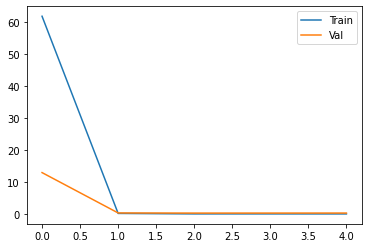

Calculating test loss:   0%|          | 0/313 [00:00<?, ?it/s]

Test batch prediction example:
Outputs: tensor([[-0.0276],
        [-0.0256],
        [-0.0267],
        [-0.0244],
        [-0.0275],
        [-0.0306],
        [-0.0276],
        [-0.0273]], device='cuda:0')
Labels:  tensor([-0.6003,  0.3934, -0.6754, -0.6003,  0.2225, -0.8624, -0.6003,  0.0686],
       device='cuda:0')


Training model:   0%|          | 0/256 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

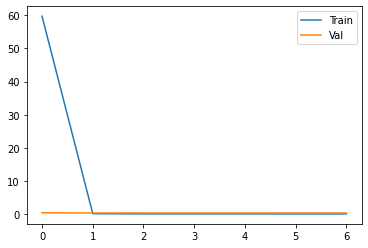

Calculating test loss:   0%|          | 0/313 [00:00<?, ?it/s]

Test batch prediction example:
Outputs: tensor([[-0.0054],
        [-0.0054],
        [-0.0054],
        [-0.0054],
        [-0.0054],
        [-0.0054],
        [-0.0054],
        [-0.0054]], device='cuda:0')
Labels:  tensor([-0.9887,  0.4741,  0.5430, -0.6329, -0.6003,  0.5164, -0.8864,  0.7741],
       device='cuda:0')


Training model:   0%|          | 0/256 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

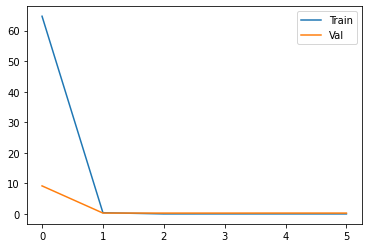

Calculating test loss:   0%|          | 0/313 [00:00<?, ?it/s]

Test batch prediction example:
Outputs: tensor([[0.0522],
        [0.0524],
        [0.0526],
        [0.0527],
        [0.0522],
        [0.0524],
        [0.0522],
        [0.0524]], device='cuda:0')
Labels:  tensor([-0.6754,  0.0038,  0.4741,  0.5430, -0.6329,  0.3934, -0.9887,  0.2225],
       device='cuda:0')


Training model:   0%|          | 0/256 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

...

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

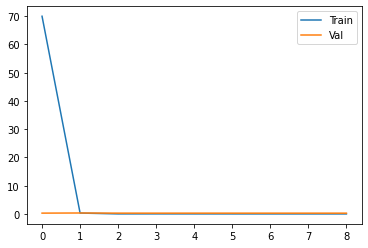

Calculating test loss:   0%|          | 0/313 [00:00<?, ?it/s]

Test batch prediction example:
Outputs: tensor([[-0.0012],
        [-0.0009],
        [ 0.0028],
        [-0.0013],
        [-0.0014],
        [-0.0008],
        [-0.0012],
        [-0.0009]], device='cuda:0')
Labels:  tensor([ 0.2147,  0.7741,  0.0861,  0.0038,  0.0686, -0.6329,  0.8341,  0.7741],
       device='cuda:0')


Training model:   0%|          | 0/256 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

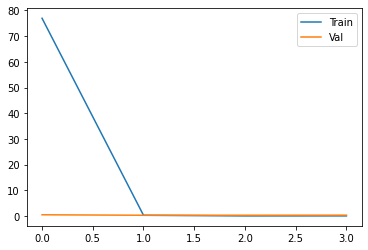

Calculating test loss:   0%|          | 0/313 [00:00<?, ?it/s]

Test batch prediction example:
Outputs: tensor([[-0.0401],
        [-0.0408],
        [-0.0226],
        [-0.0337],
        [ 0.0050],
        [-0.0328],
        [-0.0207],
        [-0.0304]], device='cuda:0')
Labels:  tensor([ 0.5540,  0.2225,  0.5430,  0.0686, -0.8624, -0.6329, -0.9887,  0.4572],
       device='cuda:0')



VALID MODELS: 65


Data Augmentation scheme:   0%|          | 0/5 [00:00<?, ?it/s]

Training model:   0%|          | 0/256 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

...

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

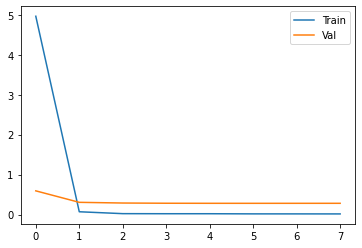

Calculating test loss:   0%|          | 0/313 [00:00<?, ?it/s]

Test batch prediction example:
Outputs: tensor([[0.0060],
        [0.0060],
        [0.0060],
        [0.0060],
        [0.0060],
        [0.0060],
        [0.0060],
        [0.0060]], device='cuda:0')
Labels:  tensor([-0.6517,  0.0861,  0.7741, -0.8624,  0.3934,  0.5430,  0.5296,  0.5430],
       device='cuda:0')


Training model:   0%|          | 0/256 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

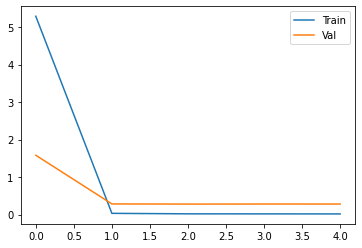

Calculating test loss:   0%|          | 0/313 [00:00<?, ?it/s]

Test batch prediction example:
Outputs: tensor([[0.0112],
        [0.0112],
        [0.0113],
        [0.0112],
        [0.0112],
        [0.0112],
        [0.0112],
        [0.0112]], device='cuda:0')
Labels:  tensor([ 0.8341,  0.4741,  0.0038, -0.8864, -0.8864,  0.5296,  0.0686, -0.8624],
       device='cuda:0')


Training model:   0%|          | 0/256 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

...

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

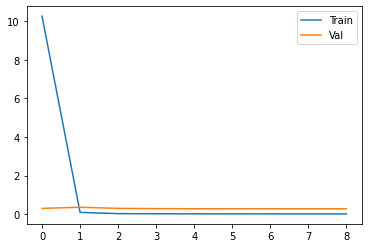

Calculating test loss:   0%|          | 0/313 [00:00<?, ?it/s]

Test batch prediction example:
Outputs: tensor([[0.0108],
        [0.0108],
        [0.0108],
        [0.0108],
        [0.0108],
        [0.0124],
        [0.0108],
        [0.0119]], device='cuda:0')
Labels:  tensor([ 0.0686,  0.0861,  0.0686, -0.1579,  0.3934, -0.6754,  0.4572, -0.6003],
       device='cuda:0')


Training model:   0%|          | 0/256 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

...

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

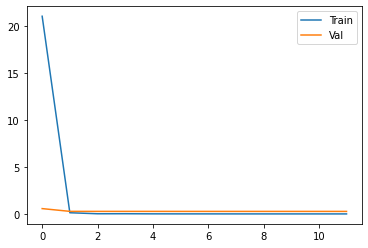

Calculating test loss:   0%|          | 0/313 [00:00<?, ?it/s]

Test batch prediction example:
Outputs: tensor([[0.0180],
        [0.0180],
        [0.0180],
        [0.0180],
        [0.0180],
        [0.0180],
        [0.0180],
        [0.0180]], device='cuda:0')
Labels:  tensor([0.7741, 0.2147, 0.0038, 0.0861, 0.0686, 0.5164, 0.4572, 0.0861],
       device='cuda:0')


Training model:   0%|          | 0/256 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

...

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/1250 [00:00<?, ?it/s]

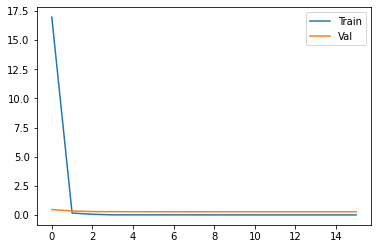

Calculating test loss:   0%|          | 0/313 [00:00<?, ?it/s]

Test batch prediction example:
Outputs: tensor([[0.0132],
        [0.0132],
        [0.0132],
        [0.0132],
        [0.0132],
        [0.0132],
        [0.0132],
        [0.0132]], device='cuda:0')
Labels:  tensor([ 0.0686, -0.9887,  0.8341,  0.5430,  0.1715,  0.8341,  0.5164, -0.1579],
       device='cuda:0')


In [12]:
# Model and training parameters
n_tests = 64
max_layers = 12
max_epochs = 256
patience = 2
lr = 1e-4
seed_value = 80000000

model_args = {"dataloader" : test_loader, # To check the input and output sizes, type of problem, etc, from
              "task" : "regression",
              "out_size" : None,
              "logmin_c" : 4, # Number of channels per layer goes from 16 to 1024
              "logmax_c" : 10,
              "max_k" : 7, # Kernel size is at most 7 px wide
              "max_iter_time" : 2, # Only train models that require at most 2 seconds per batch
              "verbose" : True}

# Create folders to save models at
os.makedirs("saved_models/", exist_ok = True)

model_save_path = "saved_models/callibration/"
os.makedirs(model_save_path, exist_ok = True)
for t in range(len(transforms)):
    os.makedirs(model_save_path+"data_aug_"+str(t), exist_ok = True)

# Load results
if os.path.exists('tr_accs.json'):
    with open('tr_accs.json', 'r') as file:
        tr_accs = json.load(file)
    with open('val_accs.json', 'r') as file:
        val_accs = json.load(file)
    with open('test_accs.json', 'r') as file:
        test_accs = json.load(file)
    with open('train_times.json', 'r') as file:
        train_times = json.load(file)
else:
    tr_accs = {"vanilla" : [],"daug1" : [],"daug2" : [],"daug3" : [], "reinit" : []}
    val_accs = {"vanilla" : [],"daug1" : [],"daug2" : [],"daug3" : [], "reinit" : []}
    test_accs = {"vanilla" : [],"daug1" : [],"daug2" : [],"daug3" : [], "reinit" : []}
    train_times = {"vanilla" : [],"daug1" : [],"daug2" : [],"daug3" : [], "reinit" : []}

with tqdm(total=n_tests, leave = False, desc='Generating and training models') as pbar_tests:
    pbar_tests.update(sum((np.array([test for test in test_accs["vanilla"] if test != None])<0.6)*(np.array([test for test in test_accs["daug1"] if test != None])<0.6)*(np.array([test for test in test_accs["daug2"] if test != None])<0.6)*(np.array([test for test in test_accs["daug3"] if test != None])<0.6)*(np.array([test for test in test_accs["reinit"] if test != None])<0.6)))
    while sum((np.array([test for test in test_accs["vanilla"] if test != None])<0.6)*(np.array([test for test in test_accs["daug1"] if test != None])<0.6)*(np.array([test for test in test_accs["daug2"] if test != None])<0.6)*(np.array([test for test in test_accs["daug3"] if test != None])<0.6)*(np.array([test for test in test_accs["reinit"] if test != None])<0.6)) < n_tests:
        seed_value += 1
        try:
            print("\n\n\nVALID MODELS:",sum((np.array([test for test in test_accs["vanilla"] if test != None])<0.6)*(np.array([test for test in test_accs["daug1"] if test != None])<0.6)*(np.array([test for test in test_accs["daug2"] if test != None])<0.6)*(np.array([test for test in test_accs["daug3"] if test != None])<0.6)*(np.array([test for test in test_accs["reinit"] if test != None])<0.6)))
            free_gpu_cache()
            set_seed(seed_value)
            base_model = optimized_network(**model_args, n_blocks = random.randint(1, max_layers), complex_classifier = random.randint(0, 1))
            accs, times = trainloop(base_model, transforms, max_epochs = max_epochs, lr = lr, patience = patience, model_save_path = model_save_path, verbose = True)
            del base_model
            
            if not accs == None:
                tr_accs["vanilla"] = tr_accs["vanilla"] + [accs["train"][0]]
                tr_accs["daug1"] = tr_accs["daug1"] + [accs["train"][1]]
                tr_accs["daug2"] = tr_accs["daug2"] + [accs["train"][2]]
                tr_accs["daug3"] = tr_accs["daug3"] + [accs["train"][3]]
                tr_accs["reinit"] = tr_accs["reinit"] + [accs["train"][4]]
                
                val_accs["vanilla"] = val_accs["vanilla"] + [accs["val"][0]]
                val_accs["daug1"] = val_accs["daug1"] + [accs["val"][1]]
                val_accs["daug2"] = val_accs["daug2"] + [accs["val"][2]]
                val_accs["daug3"] = val_accs["daug3"] + [accs["val"][3]]
                val_accs["reinit"] = val_accs["reinit"] + [accs["val"][4]]
                
                test_accs["vanilla"] = test_accs["vanilla"] + [accs["test"][0]]
                test_accs["daug1"] = test_accs["daug1"] + [accs["test"][1]]
                test_accs["daug2"] = test_accs["daug2"] + [accs["test"][2]]
                test_accs["daug3"] = test_accs["daug3"] + [accs["test"][3]]
                test_accs["reinit"] = test_accs["reinit"] + [accs["test"][4]]
    
                train_times["vanilla"] = train_times["vanilla"] + [times[0]]
                train_times["daug1"] = train_times["daug1"] + [times[1]]
                train_times["daug2"] = train_times["daug2"] + [times[2]]
                train_times["daug3"] = train_times["daug3"] + [times[3]]
                train_times["reinit"] = train_times["reinit"] + [times[4]]

                Path("tr_accs.json").write_text(json.dumps(tr_accs))
                Path("val_accs.json").write_text(json.dumps(val_accs))
                Path("test_accs.json").write_text(json.dumps(test_accs))
                Path("train_times.json").write_text(json.dumps(train_times))

                pbar_tests.update()
            else:
                try: del base_model, accs, times
                except: pass
                print("Generated useless model, retrying")
                
        except Exception as e:
            try: del base_model
            except: pass


### 1.3. Resulting accuracies and training times

In [13]:
print("tr_accs =", tr_accs)
print("val_accs =", val_accs)
print("test_accs =", test_accs)
print("train_times =", train_times)

tr_accs = {'vanilla': [23.908174995476305, 0.011507832867649049, 0.01346771385618369, 11.93912316641152, 96.89108773454882, 0.01052026239488754, 0.010761570636433898, 0.014306394921868195, 0.012963429298414268, 0.07175335243751353, 0.009842771952106704, 0.009855371960740522, 0.24732334069052944, 0.008990174521993322, 0.008655777371339936, 0.010390220522547242, 0.008654116187125254, 0.014807700018547766, 22.417192566387357, 0.014785304804194311, 86.3079748758933, 0.0650457728077122, 0.013535978065901436, 0.46544265361852943, 0.014842018744575034, 0.2923277057914632, 0.30474130213682304, 0.05960597702777712, 0.27983427323277954, 0.014764888726534555, 0.017042149026269035, 0.014880871990871384, 0.013918630825127475, 0.023671099456081066, 0.7796600840425718, 0.2836659189905785, 0.7359221710580727, 0.04210980855134781, 0.022503939689692925, 0.015101569970080745, 0.013662139716576349, 2.832895069541279, 0.04316051312424825, 0.017915954439229973, 0.3328303317723726, 0.014071953697661956, 0.01